In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Lyon"
away= "Brest"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Lyon,Nantes,2025-01-26,D,A,1,1,0,62,0,...,1.1,2.2,-0.1,-0.1,-0.1,0.07,1,1.4,0.28,0.4
19,Lyon,Marseille,2025-02-02,L,A,2,3,-1,37,1,...,0.6,0.4,0.3,0.1,0.4,0.10,0,4.2,0.40,1.2
20,Lyon,Reims,2025-02-09,W,H,4,0,4,67,0,...,3.1,1.6,0.7,0.7,0.9,0.22,0,0.1,0.08,0.1
21,Lyon,Montpellier,2025-02-16,W,A,4,1,3,62,0,...,1.0,1.1,3.0,3.0,3.0,0.11,0,1.2,0.31,0.2
22,Lyon,Paris S-G,2025-02-23,L,H,2,3,-1,35,0,...,1.5,1.0,0.2,0.2,0.5,0.13,0,2.5,0.36,-0.5


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Nantes,Lyon,2025-01-26,D,H,1,1,0,38,0,...,0.9,0.8,-0.2,-0.2,0.1,0.18,0,1.0,0.24,0.0
19,Marseille,Lyon,2025-02-02,W,H,3,2,1,63,0,...,3.0,2.2,-0.2,-0.2,0.0,0.16,0,2.1,0.27,0.1
20,Reims,Lyon,2025-02-09,L,A,0,4,-4,33,0,...,0.1,0.6,-0.4,-0.4,-0.1,0.04,1,3.4,0.38,-0.6
21,Montpellier,Lyon,2025-02-16,L,H,1,4,-3,38,0,...,1.2,1.1,-0.4,-0.4,-0.2,0.13,1,2.8,0.46,-1.2
22,Paris S-G,Lyon,2025-02-23,W,A,3,2,1,65,0,...,2.3,1.1,0.7,0.7,0.7,0.16,0,3.1,0.46,1.1


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Brest,Le Havre,2025-01-26,W,A,1,0,1,55,0,...,1.1,1.1,-1.0,-1.0,-1.1,0.12,1,0.6,0.58,0.6
19,Brest,Paris S-G,2025-02-01,L,H,2,5,-3,35,0,...,0.5,0.4,1.1,1.1,-0.5,0.06,0,4.0,0.58,-1.0
20,Brest,Nantes,2025-02-07,W,A,2,0,2,42,0,...,2.5,1.9,-0.5,-0.5,-0.5,0.25,0,0.4,0.19,0.4
21,Brest,Auxerre,2025-02-14,D,H,2,2,0,64,0,...,1.6,1.3,-0.2,-0.2,-0.6,0.12,0,1.4,0.23,-0.6
22,Brest,Strasbourg,2025-02-23,D,A,0,0,0,43,0,...,0.5,0.5,-0.6,-0.6,-0.5,0.05,0,0.3,0.31,0.3


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Le Havre,Brest,2025-01-26,L,H,0,1,-1,45,0,...,0.9,0.7,-1.0,-1.0,-0.9,0.09,0,2.0,0.28,1.0
19,Paris S-G,Brest,2025-02-01,W,A,5,2,3,65,0,...,2.9,1.5,1.4,1.4,0.1,0.26,0,1.1,0.16,-0.9
20,Nantes,Brest,2025-02-07,L,H,0,2,-2,58,0,...,0.7,1.1,-1.1,-1.1,-0.7,0.07,1,1.9,0.32,-0.1
21,Auxerre,Brest,2025-02-14,D,A,2,2,0,36,0,...,0.9,0.9,0.8,0.8,0.1,0.11,1,2.0,0.34,0.0
22,Strasbourg,Brest,2025-02-23,D,H,0,0,0,57,0,...,0.4,1.0,-0.6,-0.6,-0.4,0.20,0,0.1,0.07,0.1


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'Poss', 'PKatt', 'G-PK', 'PK', 'PKm', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,1,0,0,62,0,12,3,25.0,9,75.0,...,-0.1,-0.1,1.1,2.2,-0.1,-0.1,-0.1,0.07,1,1
19,1,1,0,37,1,13,3,23.1,8,61.5,...,-1.5,-2.3,0.6,0.4,0.3,0.1,0.4,0.10,0,2
20,4,0,0,67,0,15,8,53.3,6,40.0,...,2.9,2.9,3.1,1.6,0.7,0.7,0.9,0.22,0,4
21,4,0,0,62,0,12,5,41.7,5,41.7,...,-0.4,-0.4,1.0,1.1,3.0,3.0,3.0,0.11,0,4
22,2,0,0,35,0,23,10,43.5,12,52.2,...,-0.5,-0.5,1.5,1.0,0.2,0.2,0.5,0.13,0,2


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,1,0,0,38,0,18,9,50.0,9,50.0,...,0.1,0.1,0.9,0.8,-0.2,-0.2,0.1,0.18,0,1
19,3,0,0,63,0,8,3,37.5,5,62.5,...,1.5,2.3,3.0,2.2,-0.2,-0.2,0.0,0.16,0,3
20,0,0,0,33,0,29,8,27.6,19,65.5,...,-2.9,-2.9,0.1,0.6,-0.4,-0.4,-0.1,0.04,1,0
21,1,0,0,38,0,16,12,75.0,4,25.0,...,0.4,0.4,1.2,1.1,-0.4,-0.4,-0.2,0.13,1,1
22,3,0,0,65,0,23,18,78.3,2,8.7,...,0.5,0.5,2.3,1.1,0.7,0.7,0.7,0.16,0,3


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,1,0,0,55,0,20,8,40.0,8,40.0,...,1.0,1.0,1.1,1.1,-1.0,-1.0,-1.1,0.12,1,1
19,2,0,0,35,0,12,5,41.7,5,41.7,...,-2.7,-2.7,0.5,0.4,1.1,1.1,-0.5,0.06,0,2
20,2,0,0,42,0,10,2,20.0,7,70.0,...,1.4,1.4,2.5,1.9,-0.5,-0.5,-0.5,0.25,0,2
21,2,0,0,64,0,15,5,33.3,9,60.0,...,1.0,1.0,1.6,1.3,-0.2,-0.2,-0.6,0.12,0,2
22,0,0,0,43,0,15,6,40.0,7,46.7,...,0.0,0.0,0.5,0.5,-0.6,-0.6,-0.5,0.05,0,0


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,0,0,0,45,0,15,8,53.3,6,40.0,...,-1.0,-1.0,0.9,0.7,-1.0,-1.0,-0.9,0.09,0,0
19,5,0,0,65,0,13,2,15.4,9,69.2,...,2.7,2.7,2.9,1.5,1.4,1.4,0.1,0.26,0,5
20,0,0,0,58,0,18,5,27.8,13,72.2,...,-1.4,-1.4,0.7,1.1,-1.1,-1.1,-0.7,0.07,1,0
21,2,0,0,36,0,12,5,41.7,7,58.3,...,-1.0,-1.0,0.9,0.9,0.8,0.8,0.1,0.11,1,2
22,0,0,0,57,0,14,7,50.0,5,35.7,...,0.0,0.0,0.4,1.0,-0.6,-0.6,-0.4,0.20,0,0


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
18,21,2,9.5,0,0,5.8,0,NaN,0,0,...,1,9,7,25,31,0,1.4,0.28,0.4,1
19,13,0,0.0,0,2,24.0,0,NaN,0,0,...,0,5,12,23,34,0,4.2,0.40,1.2,3
20,15,1,6.7,0,0,4.8,0,NaN,0,0,...,2,9,6,32,23,0,0.1,0.08,0.1,0
21,20,2,10.0,0,0,4.7,0,NaN,0,0,...,4,4,5,12,35,1,1.2,0.31,0.2,1
22,10,2,20.0,0,0,11.8,0,NaN,0,0,...,5,6,8,24,14,0,2.5,0.36,-0.5,3


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
18,13,0,0.0,0,1,15.5,0,NaN,0,0,...,5,13,6,25,26,0,1.0,0.24,0.0,1
19,8,4,50.0,1,2,13.8,0,0.0,0,0,...,3,8,8,26,16,1,2.1,0.27,0.1,2
20,11,1,9.1,0,1,13.8,0,NaN,0,0,...,2,8,11,25,23,0,3.4,0.38,-0.6,4
21,6,0,0.0,0,0,NaN,0,NaN,0,0,...,2,13,9,22,17,0,2.8,0.46,-1.2,4
22,13,0,0.0,0,0,12.7,0,NaN,0,0,...,4,8,10,25,21,0,3.1,0.46,1.1,2


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,1,0,0.0,2,2,20.7,0,0.0,0,0,...,1,13,9,37,3,0,3.0,0.24,-2.0,5
1,18,1,5.6,0,0,8.0,0,NaN,0,0,...,5,6,19,31,24,0,1.8,0.20,0.8,2
2,12,2,16.7,0,0,10.0,0,NaN,0,0,...,2,4,8,31,19,0,0.0,NaN,0.0,0
3,14,1,7.1,0,0,3.5,0,NaN,0,0,...,6,11,8,36,30,0,2.9,0.32,-0.1,3
4,20,0,0.0,1,0,11.0,0,NaN,0,0,...,1,6,13,25,35,0,0.1,0.06,0.1,0


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,15,0,0.0,1,0,10.0,1,100.0,0,0,...,1,10,11,29,20,1,1.7,0.15,0.7,1
1,13,3,23.1,0,0,4.7,0,NaN,0,0,...,0,6,10,26,15,0,0.5,0.23,0.5,0
2,19,1,5.3,2,1,15.5,0,0.0,0,1,...,6,6,5,23,28,2,3.5,0.23,-0.5,4
3,9,0,0.0,1,0,20.0,0,0.0,0,0,...,2,10,5,19,7,0,1.1,0.10,0.1,1
4,15,0,0.0,0,1,18.5,0,NaN,0,0,...,2,6,10,32,18,0,0.6,0.12,-1.4,2


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,8,4,66.7,1,0,0,11,14,40
19,11,12,47.8,1,0,0,10,12,32
20,11,5,68.8,2,0,0,10,11,47
21,10,11,47.6,1,0,0,12,13,21
22,3,7,30.0,1,0,0,12,8,38


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,4,8,33.3,3,0,0,14,10,44
19,12,11,52.2,4,0,0,13,9,43
20,5,11,31.3,2,1,0,12,10,46
21,11,10,52.4,3,0,0,14,9,37
22,7,3,70.0,1,0,0,8,12,48


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,29,21,58.0,3,0,0,14,12,39
19,14,9,60.9,1,0,0,9,11,50
20,22,17,56.4,2,0,0,13,14,45
21,20,23,46.5,2,0,0,9,11,54
22,10,15,40.0,1,0,0,12,11,43


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,21,29,42.0,2,0,0,12,14,40
19,9,14,39.1,0,0,0,12,9,44
20,17,22,43.6,3,0,0,15,13,39
21,23,20,53.5,2,0,0,12,8,47
22,15,10,60.0,3,0,0,12,11,38


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,1,0,0,62,0,12,3,25.0,9,75.0,...,-0.750,0.450925,-0.300,0.182574,0.135,0.058023,0.25,0.50000,0.75,0.500000
19,1,1,0,37,1,13,3,23.1,8,61.5,...,-0.650,0.556776,-0.300,0.182574,0.100,0.035590,0.50,0.57735,0.75,0.500000
20,4,0,0,67,0,15,8,53.3,6,40.0,...,-0.275,0.350000,-0.075,0.340343,0.095,0.033166,0.50,0.57735,1.00,0.816497
21,4,0,0,62,0,12,5,41.7,5,41.7,...,0.000,0.577350,0.200,0.571548,0.115,0.071414,0.50,0.57735,1.75,1.707825
22,2,0,0,35,0,23,10,43.5,12,52.2,...,0.925,1.424488,1.050,1.362596,0.125,0.065574,0.25,0.50000,2.75,1.500000


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,1,0,0,38,0,18,9,50.0,9,50.0,...,-0.375,0.984463,-0.525,0.590903,0.1100,0.048305,0.25,0.50000,1.25,1.500000
19,3,0,0,63,0,8,3,37.5,5,62.5,...,-0.400,0.976388,-0.425,0.670199,0.1100,0.048305,0.25,0.50000,0.75,0.957427
20,0,0,0,33,0,29,8,27.6,19,65.5,...,-0.150,0.818535,-0.200,0.605530,0.1325,0.044253,0.00,0.00000,1.50,1.290994
21,1,0,0,38,0,16,12,75.0,4,25.0,...,-0.475,0.427200,-0.275,0.556028,0.1175,0.064485,0.25,0.50000,1.00,1.414214
22,3,0,0,65,0,23,18,78.3,2,8.7,...,-0.300,0.115470,-0.050,0.129099,0.1275,0.061847,0.50,0.57735,1.25,1.258306


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,19,1,5.3,0,0,5.0,0,0.0,0,0,...,0.50,0.57735,1.475,0.464579,0.4275,0.375888,0.225,0.427200,1.25,0.500000
19,12,0,0.0,0,0,13.5,0,0.0,0,0,...,0.50,0.57735,1.400,0.594418,0.5400,0.320416,0.400,0.391578,1.00,0.816497
20,33,2,6.1,0,2,12.8,0,0.0,0,0,...,0.25,0.50000,1.925,1.468276,0.4450,0.179907,0.175,0.809835,1.75,2.217356
21,6,0,0.0,0,3,20.1,0,0.0,0,0,...,0.25,0.50000,1.700,1.653280,0.3875,0.222317,0.200,0.816497,1.50,2.380476
22,11,3,27.3,0,4,19.8,0,0.0,0,0,...,0.25,0.50000,1.600,1.657307,0.3950,0.214243,-0.150,0.772442,1.75,2.362908


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,18,0,0.0,0,0,8.0,0,0.0,0,1,...,0.25,0.50000,1.550,0.544671,0.3275,0.109962,-4.500000e-01,1.558846,2.00,1.632993
19,10,0,0.0,0,1,12.7,0,0.0,0,0,...,0.50,0.57735,1.500,0.469042,0.3275,0.109962,2.500000e-01,1.367479,1.25,0.957427
20,18,1,5.6,0,0,10.0,0,0.0,0,0,...,0.75,0.50000,1.325,0.450000,0.2550,0.097125,-4.250000e-01,0.950000,1.75,0.500000
21,25,0,0.0,0,2,18.5,0,0.0,0,0,...,0.75,0.50000,1.525,0.492443,0.2850,0.092916,-2.250000e-01,0.899537,1.75,0.500000
22,16,1,6.3,0,1,15.0,0,0.0,0,0,...,0.75,0.50000,1.750,0.435890,0.2750,0.080623,-6.938894e-18,0.778888,1.75,0.500000


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,1,0,0,55,0,20,8,40.0,8,40.0,...,0.725,1.252664,0.475,1.065755,0.1075,0.029861,0.00,0.0,2.00,1.632993
19,2,0,0,35,0,12,5,41.7,5,41.7,...,-0.025,1.126573,-0.075,1.195478,0.1000,0.016330,0.25,0.5,1.25,0.957427
20,2,0,0,42,0,10,2,20.0,7,70.0,...,0.500,1.003328,0.025,1.117661,0.0950,0.025166,0.25,0.5,1.75,0.500000
21,2,0,0,64,0,15,5,33.3,9,60.0,...,0.150,1.059874,-0.150,1.135782,0.1325,0.082209,0.25,0.5,1.75,0.500000
22,0,0,0,43,0,15,6,40.0,7,46.7,...,-0.150,0.896289,-0.675,0.287228,0.1375,0.080156,0.25,0.5,1.75,0.500000


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,0,0,0,45,0,15,8,53.3,6,40.0,...,-0.200,0.316228,0.050,0.369685,0.1325,0.085000,0.00,0.00000,1.25,0.500000
19,5,0,0,65,0,13,2,15.4,9,69.2,...,-0.425,0.492443,-0.225,0.573730,0.1375,0.080571,0.00,0.00000,1.00,0.816497
20,0,0,0,58,0,18,5,27.8,13,72.2,...,-0.125,1.050000,-0.325,0.419325,0.1400,0.085245,0.00,0.00000,1.75,2.217356
21,2,0,0,36,0,12,5,41.7,7,58.3,...,-0.300,1.163329,-0.450,0.443471,0.1225,0.092150,0.25,0.50000,1.50,2.380476
22,0,0,0,57,0,14,7,50.0,5,35.7,...,0.025,1.265899,-0.350,0.525991,0.1325,0.086554,0.50,0.57735,1.75,2.362908


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,21,2,9.5,0,0,5.8,0,0.0,0,0,...,1.25,1.892969,1.150,1.096966,0.1750,0.124766,-0.100,0.648074,1.25,1.500000
19,13,0,0.0,0,2,24.0,0,0.0,0,0,...,0.25,0.500000,0.825,0.531507,0.1600,0.099331,0.075,0.670199,0.75,0.957427
20,15,1,6.7,0,0,4.8,0,0.0,0,0,...,0.00,0.000000,1.725,1.726992,0.2350,0.142712,0.225,0.865544,1.50,1.290994
21,20,2,10.0,0,0,4.7,0,0.0,0,0,...,0.00,0.000000,1.475,1.910279,0.2050,0.163605,0.475,0.499166,1.00,1.414214
22,10,2,20.0,0,0,11.8,0,0.0,0,0,...,0.25,0.500000,1.725,1.746186,0.2675,0.135000,0.475,0.499166,1.25,1.258306


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,13,0,0.0,0,1,15.5,0,0.0,0,0,...,0.25,0.5,0.725,0.478714,0.3225,0.187328,0.225,0.250000,0.75,0.500000
19,8,4,50.0,1,2,13.8,0,0.0,0,0,...,0.00,0.0,0.750,0.493288,0.3075,0.192072,0.250,0.208167,0.75,0.500000
20,11,1,9.1,0,1,13.8,0,0.0,0,0,...,0.25,0.5,1.150,0.785281,0.2500,0.143527,0.150,0.129099,1.00,0.816497
21,6,0,0.0,0,0,0.0,0,0.0,0,0,...,0.25,0.5,1.675,1.388944,0.2400,0.128323,-0.075,0.359398,1.75,1.707825
22,13,0,0.0,0,0,12.7,0,0.0,0,0,...,0.25,0.5,2.325,1.030776,0.3375,0.101448,-0.425,0.602080,2.75,1.500000


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
18,8,4,66.7,1,0,0,11,14,40,10.50,...,0.0,0.0,0.0,0.0,8.50,1.000000,8.50,1.914854,47.5,4.509250
19,11,12,47.8,1,0,0,10,12,32,12.00,...,0.0,0.0,0.0,0.0,9.25,1.500000,10.50,2.516611,45.5,5.802298
20,11,5,68.8,2,0,0,10,11,47,11.75,...,0.0,0.0,0.0,0.0,9.75,1.258306,11.00,2.581989,41.0,7.788881
21,10,11,47.6,1,0,0,12,13,21,9.50,...,0.0,0.0,0.0,0.0,9.75,1.258306,11.25,2.500000,42.5,8.346656
22,3,7,30.0,1,0,0,12,8,38,10.00,...,0.0,0.0,0.0,0.0,10.75,0.957427,12.50,1.290994,35.0,11.165423


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
18,4,8,33.3,3,0,0,14,10,44,11.50,...,0.00,0.0,0.0,0.0,8.75,1.500000,8.50,1.000000,41.25,7.088723
19,12,11,52.2,4,0,0,13,9,43,10.25,...,0.00,0.0,0.0,0.0,10.50,2.516611,9.00,1.154701,40.75,6.701990
20,5,11,31.3,2,1,0,12,10,46,10.75,...,0.00,0.0,0.0,0.0,11.25,2.753785,9.25,0.957427,41.00,6.782330
21,11,10,52.4,3,0,0,14,9,37,7.75,...,0.25,0.5,0.0,0.0,11.75,2.629956,9.25,0.957427,44.75,1.500000
22,7,3,70.0,1,0,0,8,12,48,8.00,...,0.25,0.5,0.0,0.0,13.25,0.957427,9.50,0.577350,42.50,3.872983


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
18,29,21,58.0,3,0,0,14,12,39,15.00,...,0.0,0.0,0.0,0.0,10.50,0.577350,12.25,1.500000,42.00,7.527727
19,14,9,60.9,1,0,0,9,11,50,19.75,...,0.0,0.0,0.0,0.0,11.50,1.732051,12.00,1.414214,39.75,6.396614
20,22,17,56.4,2,0,0,13,14,45,18.50,...,0.0,0.0,0.0,0.0,11.00,2.160247,11.50,1.290994,41.25,8.180261
21,20,23,46.5,2,0,0,9,11,54,19.75,...,0.0,0.0,0.0,0.0,11.75,2.217356,12.50,1.290994,44.75,4.500000
22,10,15,40.0,1,0,0,12,11,43,21.25,...,0.0,0.0,0.0,0.0,11.25,2.629956,12.00,1.414214,47.00,6.480741


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
18,21,29,42.0,2,0,0,12,14,40,19.75,...,0.0,0.0,0.0,0.0,12.75,1.892969,10.00,0.816497,40.50,9.000000
19,9,14,39.1,0,0,0,12,9,44,21.25,...,0.0,0.0,0.0,0.0,12.25,1.707825,11.00,2.160247,41.75,8.301606
20,17,22,43.6,3,0,0,15,13,39,19.75,...,0.0,0.0,0.0,0.0,11.75,1.258306,11.00,2.160247,44.50,5.916080
21,23,20,53.5,2,0,0,12,8,47,19.00,...,0.0,0.0,0.0,0.0,13.00,1.414214,11.75,2.217356,44.00,6.377042
22,15,10,60.0,3,0,0,12,11,38,17.50,...,0.0,0.0,0.0,0.0,12.75,1.500000,11.00,2.943920,42.50,3.696846


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,2,0,0,35,0,23,10,43.5,12,52.2,...,0.5,1.6,1.657307,0.395,0.214243,-0.15,0.772442,1.75,2.362908,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,0,1,53,1,23,5,21.7,15,65.2,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,H,0
1,0,0,0,40,0,24,8,33.3,15,62.5,...,0.0,0.0,12.000000,0.000000,8.000000,0.000000,45.000000,0.000000,H,4
2,4,0,0,48,0,17,7,41.2,9,52.9,...,0.0,0.0,9.500000,3.535534,9.000000,1.414214,43.500000,2.121320,A,0
3,0,0,0,46,0,14,5,35.7,7,50.0,...,0.0,0.0,10.333333,2.886751,14.333333,9.291573,41.333333,4.041452,H,2
4,2,0,1,63,1,21,11,52.4,9,42.9,...,0.0,0.0,11.000000,2.708013,12.500000,8.426150,44.750000,7.588368,A,2


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,10,2,20.0,0,0,11.8,0,0.0,0,0,...,0.0,0.0,0.0,11.25,2.629956,12.0,1.414214,47.0,6.480741,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,9,0,0.0,0,4,22.2,0,0.0,1,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,H,2
1,22,2,9.1,0,0,6.0,0,0.0,0,0,...,0.0,0.0,12.000000,0.000000,8.000000,0.000000,45.000000,0.000000,H,3
2,7,2,28.6,0,0,10.0,0,0.0,0,1,...,0.0,0.0,9.500000,3.535534,9.000000,1.414214,43.500000,2.121320,A,0
3,16,1,6.3,0,2,19.2,0,0.0,0,0,...,0.0,0.0,10.333333,2.886751,14.333333,9.291573,41.333333,4.041452,H,3
4,5,0,0.0,0,3,21.6,0,0.0,0,0,...,0.0,0.0,11.000000,2.708013,12.500000,8.426150,44.750000,7.588368,A,1


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,0,0,0,43,0,15,6,40.0,7,46.7,...,0.0,0.0,0.0,11.25,2.629956,12.0,1.414214,47.0,6.480741,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,1,0,1,50,1,19,5,26.3,13,68.4,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A,0
1,0,0,0,48,0,20,9,45.0,11,55.0,...,0.0,0.0,12.000000,0.000000,8.000000,0.000000,45.000000,0.000000,H,4
2,2,2,0,47,2,14,3,21.4,10,71.4,...,0.0,0.0,9.500000,3.535534,9.000000,1.414214,43.500000,2.121320,A,1
3,0,1,0,33,1,12,6,50.0,6,50.0,...,0.0,0.0,10.333333,2.886751,14.333333,9.291573,41.333333,4.041452,H,2
4,2,0,0,43,0,28,11,39.3,15,53.6,...,0.0,0.0,11.000000,2.708013,12.500000,8.426150,44.750000,7.588368,A,0


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,11,3,27.3,0,4,19.8,0,0.0,0,0,...,0.0,0.0,0.0,11.25,2.629956,12.0,1.414214,47.0,6.480741,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,1,0,0.0,2,2,20.7,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A,2
1,18,1,5.6,0,0,8.0,0,0.0,0,0,...,0.0,0.0,12.000000,0.000000,8.000000,0.000000,45.000000,0.000000,H,0
2,12,2,16.7,0,0,10.0,0,0.0,0,0,...,0.0,0.0,9.500000,3.535534,9.000000,1.414214,43.500000,2.121320,A,3
3,14,1,7.1,0,0,3.5,0,0.0,0,0,...,0.0,0.0,10.333333,2.886751,14.333333,9.291573,41.333333,4.041452,H,0
4,20,0,0.0,1,0,11.0,0,0.0,0,0,...,0.0,0.0,11.000000,2.708013,12.500000,8.426150,44.750000,7.588368,A,3


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

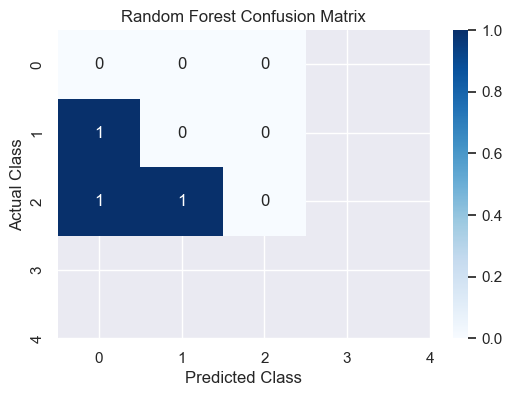

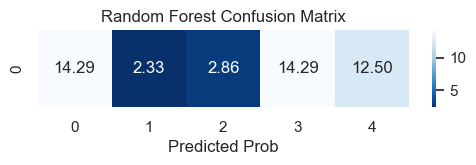

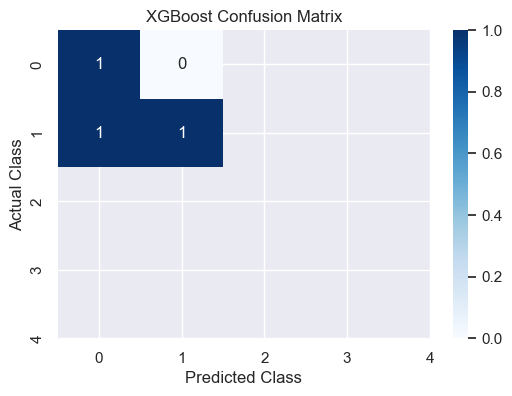

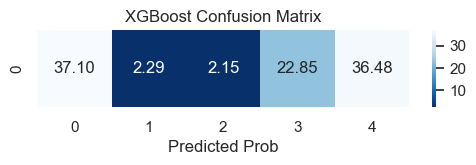

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

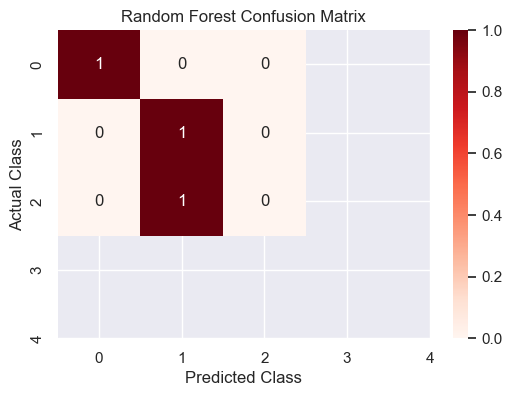

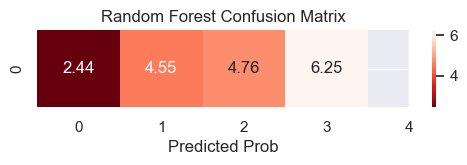

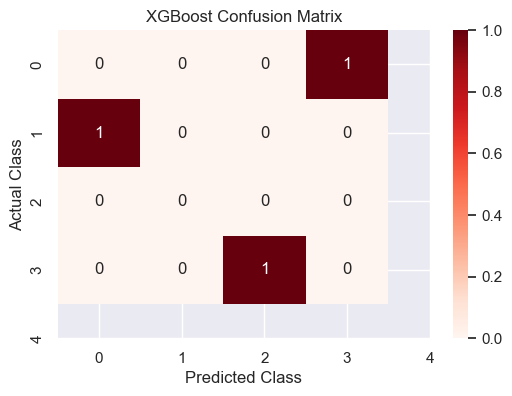

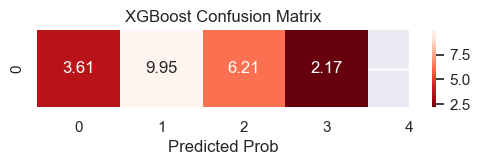

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

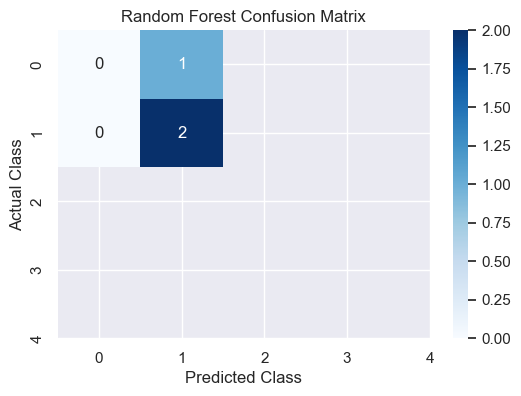

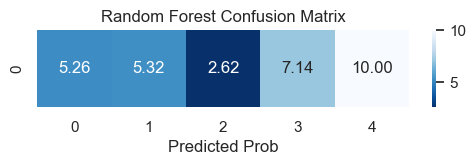

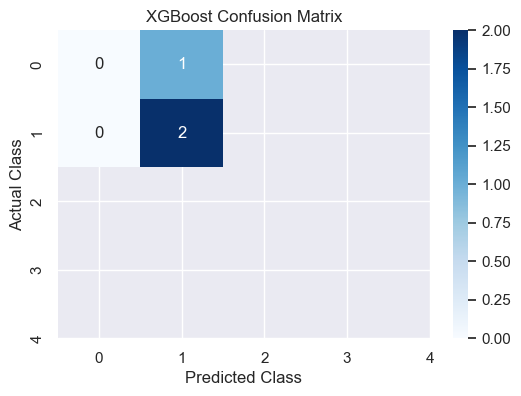

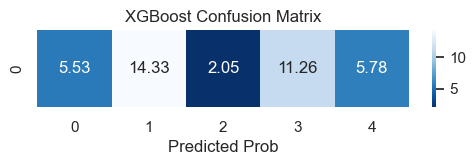

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

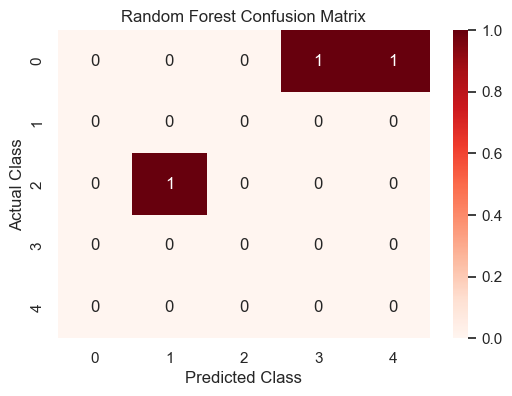

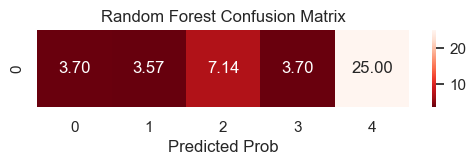

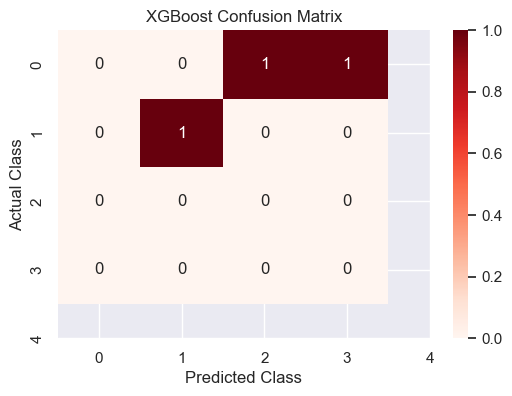

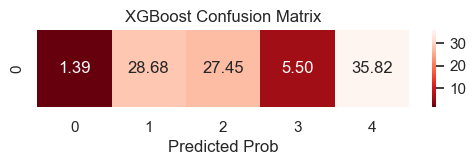

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

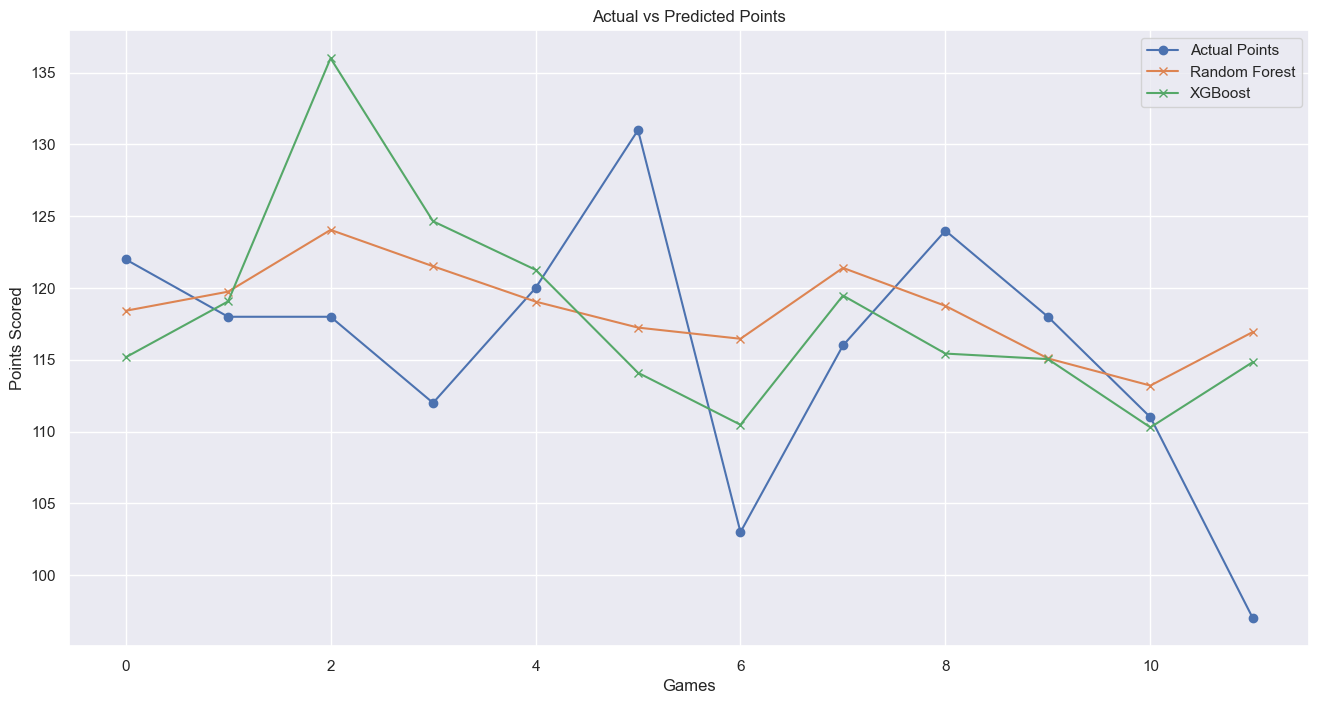

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
